# Лабораторная работа 2. Свёрточные нейронные сети

**Задача:** многоклассовая классификация спутниковых снимков (EuroSAT)  
**Датасет:** EuroSAT — 27 000 изображений 64×64 RGB, 10 классов земного покрова (Sentinel-2)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import copy
import os

# Воспроизводимость
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


## Этап 1. Загрузка и подготовка данных

**EuroSAT** — датасет спутниковых снимков Sentinel-2 для классификации земного покрова.

- 27 000 изображений, 64×64 пикселей, RGB
- 10 классов: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake
- Источник: [Helber et al., 2019](https://ieeexplore.ieee.org/document/8736785)

In [2]:
# Загрузка EuroSAT (только ToTensor для начала, нормализацию добавим после вычисления статистик)
base_transform = transforms.Compose([
    transforms.ToTensor()
])

full_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=base_transform)

CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Всего изображений: {len(full_dataset)}')
print(f'Количество классов: {NUM_CLASSES}')
print(f'Названия классов: {CLASS_NAMES}')
print(f'Размер изображения: {full_dataset[0][0].shape}')

100%|██████████| 94.3M/94.3M [00:00<00:00, 319MB/s]


Всего изображений: 27000
Количество классов: 10
Названия классов: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Размер изображения: torch.Size([3, 64, 64])


In [3]:
# Разделение на train/val/test = 80/10/10
n_total = len(full_dataset)
n_test = int(0.1 * n_total)
n_val = int(0.1 * n_total)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 21600, Val: 2700, Test: 2700


In [4]:
# Вычисление mean и std по train-выборке
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    n_samples = 0
    for images, _ in loader:
        batch_size = images.size(0)
        images = images.view(batch_size, 3, -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        n_samples += batch_size
    mean /= n_samples
    std /= n_samples
    return mean, std

train_mean, train_std = compute_mean_std(train_dataset)
print(f'Train mean: {train_mean}')
print(f'Train std:  {train_std}')

Train mean: tensor([0.3439, 0.3800, 0.4077])
Train std:  tensor([0.0912, 0.0651, 0.0552])


In [5]:
# Пересоздание датасетов с нормализацией
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# Обёртка для применения разных трансформов к подмножествам
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset.dataset[self.subset.indices[idx]]
        # img — PIL Image (т.к. исходный dataset применяет base_transform,
        # но нам нужен raw PIL), поэтому загружаем заново
        # Используем доступ через .dataset.samples или loader
        return img, label

    def __len__(self):
        return len(self.subset)

# Проще: пересоздать полный датасет без трансформа и применять трансформ в обёртке
class EuroSATSubset(torch.utils.data.Dataset):
    """Подмножество EuroSAT с настраиваемым transform."""
    def __init__(self, full_dataset, indices, transform):
        self.full_dataset = full_dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        # Загружаем сырое изображение (PIL) — минуя transform исходного датасета
        img_path, label = self.full_dataset.samples[real_idx]
        from PIL import Image
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.indices)

# Индексы из random_split
train_indices = train_dataset.indices
val_indices = val_dataset.indices
test_indices = test_dataset.indices

train_ds = EuroSATSubset(full_dataset, train_indices, train_transform)
val_ds = EuroSATSubset(full_dataset, val_indices, val_test_transform)
test_ds = EuroSATSubset(full_dataset, test_indices, val_test_transform)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 338, val: 43, test: 43


### Примеры изображений из датасета EuroSAT

По 2 примера из каждого класса — спутниковые снимки Sentinel-2, 64×64 RGB.

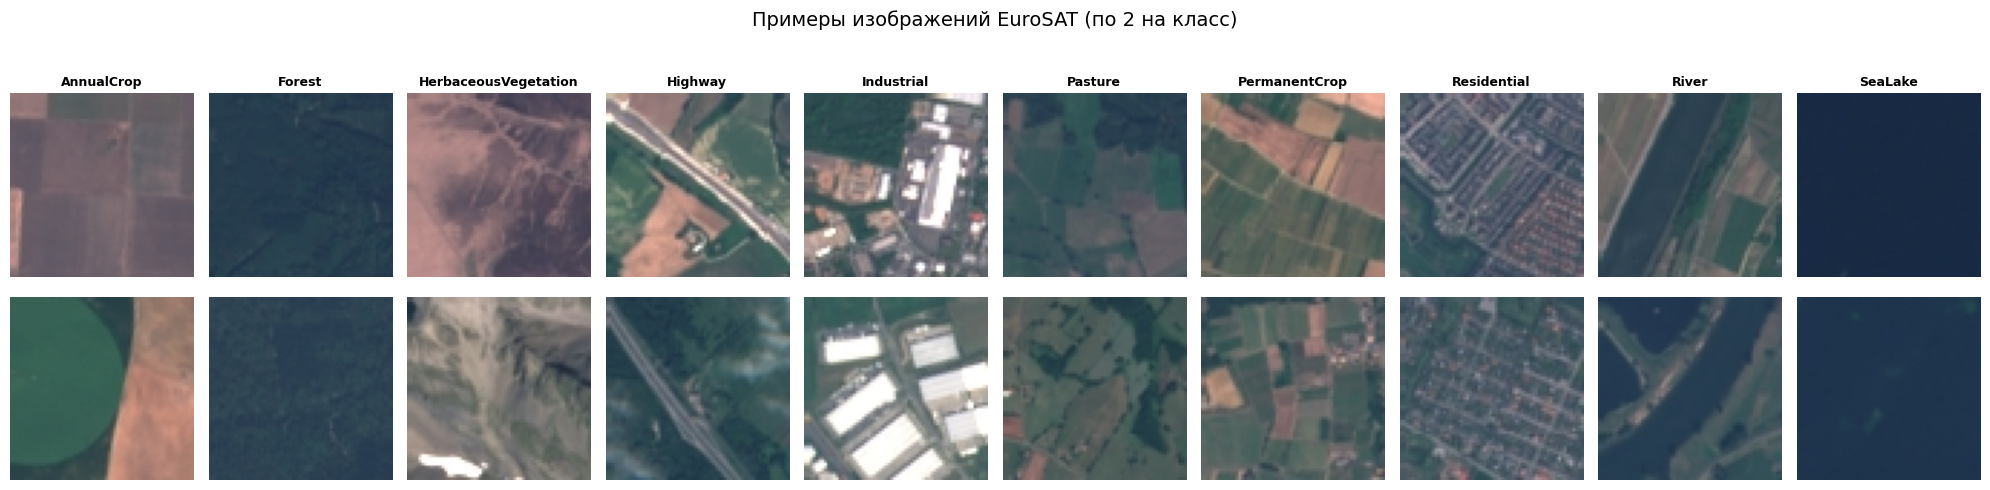

Сохранено: dataset_examples.png


In [6]:
# Визуализация примеров изображений — по 2 примера на каждый класс (сетка 2×10)
from PIL import Image

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 5))
fig.suptitle('Примеры изображений EuroSAT (по 2 на класс)', fontsize=14, y=1.02)

# Собираем по 2 примера каждого класса
class_examples = {i: [] for i in range(NUM_CLASSES)}
for idx in range(len(full_dataset)):
    img_path, label = full_dataset.samples[idx]
    if len(class_examples[label]) < 2:
        img = Image.open(img_path).convert('RGB')
        class_examples[label].append(img)
    if all(len(v) == 2 for v in class_examples.values()):
        break

for cls_idx in range(NUM_CLASSES):
    for row in range(2):
        ax = axes[row, cls_idx]
        ax.imshow(class_examples[cls_idx][row])
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: dataset_examples.png')

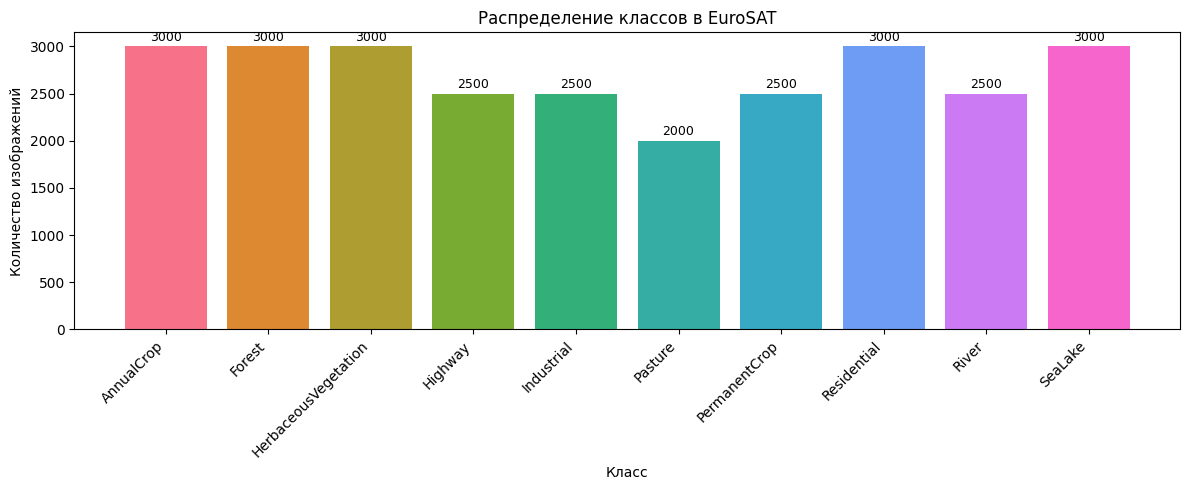

In [7]:
# Распределение классов
all_labels = [full_dataset.samples[idx][1] for idx in range(len(full_dataset))]
class_counts = [all_labels.count(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(12, 5))
bars = plt.bar(CLASS_NAMES, class_counts, color=sns.color_palette('husl', NUM_CLASSES))
plt.xlabel('Класс')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в EuroSAT')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Задание 1. Baseline CNN (максимальная оценка — 8)

Архитектура:
- **Block 1:** Conv2d(3→32, 3×3) → BatchNorm2d → ReLU → MaxPool2d(2)
- **Block 2:** Conv2d(32→64, 3×3) → BatchNorm2d → ReLU → MaxPool2d(2)
- **Classifier:** Flatten → Linear(64×16×16, 256) → ReLU → Dropout(0.3) → Linear(256, 10)

Компоненты: Conv2d (2), MaxPool2d (2), BatchNorm2d (2), ReLU, Linear (2 + выходной), Dropout (1).

Dropout (p=0.3) размещён перед последним полносвязным слоем в классификаторе — это стандартная практика, позволяющая бороться с переобучением на этапе принятия решения, не мешая извлечению признаков в свёрточных слоях.

In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Свёрточная часть
        self.features = nn.Sequential(
            # Block 1: 64x64 → 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32x32 → 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(NUM_CLASSES).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nВсего параметров: {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Всего параметров: 4,216,714
Обучаемых параметров: 4,216,714


In [9]:
# Функции обучения и валидации
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total += images.size(0)
    return running_loss / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, num_epochs=20, patience=5, scheduler=None):
    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_acc)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:>3}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Acc: {val_acc:.4f} | '
              f'LR: {current_lr:.6f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if patience and epochs_no_improve >= patience:
            print(f'\nEarly stopping на эпохе {epoch+1} (patience={patience})')
            break

    # Восстановить лучшую модель
    if best_model_state:
        model.load_state_dict(best_model_state)
    print(f'\nЛучшая Val Accuracy: {best_val_acc:.4f}')
    return history

In [10]:
# Обучение Baseline CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('=== Обучение Baseline CNN ===')
baseline_history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    device, num_epochs=20, patience=5
)

=== Обучение Baseline CNN ===
Epoch   1/20 | Train Loss: 1.1652 | Val Acc: 0.7437 | LR: 0.001000
Epoch   2/20 | Train Loss: 0.7861 | Val Acc: 0.8030 | LR: 0.001000
Epoch   3/20 | Train Loss: 0.6711 | Val Acc: 0.8311 | LR: 0.001000
Epoch   4/20 | Train Loss: 0.6160 | Val Acc: 0.8141 | LR: 0.001000
Epoch   5/20 | Train Loss: 0.5467 | Val Acc: 0.8219 | LR: 0.001000
Epoch   6/20 | Train Loss: 0.4935 | Val Acc: 0.8215 | LR: 0.001000
Epoch   7/20 | Train Loss: 0.4688 | Val Acc: 0.8467 | LR: 0.001000
Epoch   8/20 | Train Loss: 0.4232 | Val Acc: 0.8548 | LR: 0.001000
Epoch   9/20 | Train Loss: 0.4084 | Val Acc: 0.8607 | LR: 0.001000
Epoch  10/20 | Train Loss: 0.3595 | Val Acc: 0.8559 | LR: 0.001000
Epoch  11/20 | Train Loss: 0.3423 | Val Acc: 0.8652 | LR: 0.001000
Epoch  12/20 | Train Loss: 0.3194 | Val Acc: 0.8504 | LR: 0.001000
Epoch  13/20 | Train Loss: 0.2823 | Val Acc: 0.8337 | LR: 0.001000
Epoch  14/20 | Train Loss: 0.2920 | Val Acc: 0.8656 | LR: 0.001000
Epoch  15/20 | Train Loss: 0.257

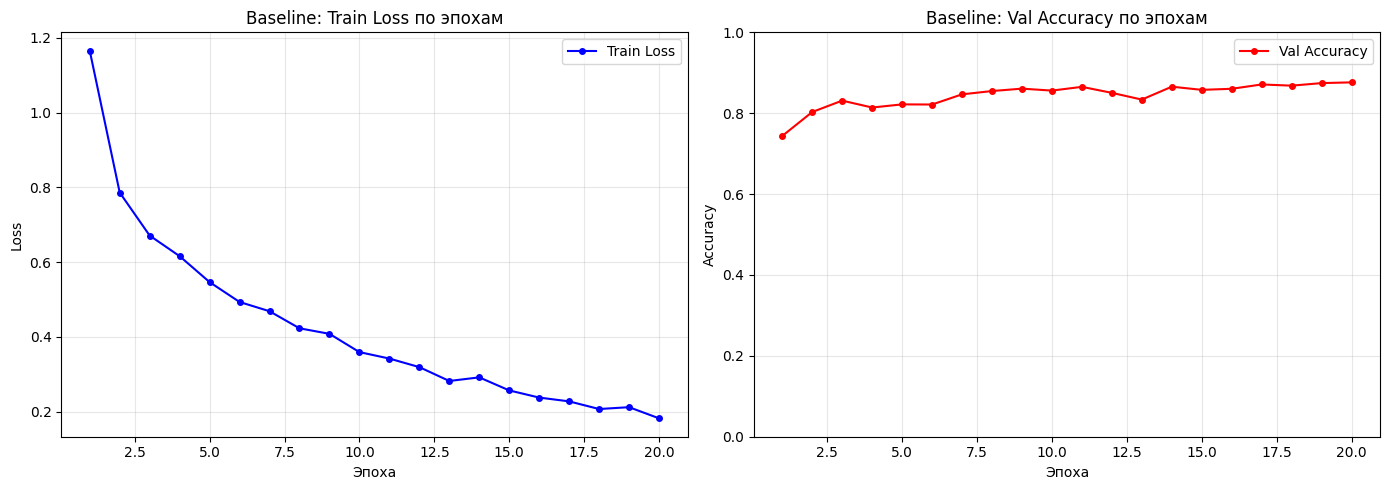

In [11]:
# Графики обучения baseline
def plot_training_history(history, title_prefix=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title_prefix}Train Loss по эпохам')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['val_acc'], 'r-o', markersize=4, label='Val Accuracy')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title_prefix}Val Accuracy по эпохам')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    return fig

fig = plot_training_history(baseline_history, 'Baseline: ')
fig.savefig('baseline_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Оценка baseline на тестовом наборе
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

baseline_preds, baseline_labels = get_predictions(model, test_loader, device)
baseline_test_acc = (baseline_preds == baseline_labels).mean()
print(f'Baseline Test Accuracy: {baseline_test_acc:.4f}')
print(f'\nClassification Report:\n')
print(classification_report(baseline_labels, baseline_preds, target_names=CLASS_NAMES))

Baseline Test Accuracy: 0.8852

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.94      0.91       300
              Forest       0.97      0.96      0.96       297
HerbaceousVegetation       0.87      0.77      0.82       302
             Highway       0.74      0.88      0.80       269
          Industrial       0.94      0.91      0.92       257
             Pasture       0.88      0.92      0.90       187
       PermanentCrop       0.83      0.77      0.80       254
         Residential       0.97      0.92      0.94       314
               River       0.82      0.82      0.82       245
             SeaLake       0.96      0.97      0.96       275

            accuracy                           0.89      2700
           macro avg       0.88      0.88      0.88      2700
        weighted avg       0.89      0.89      0.89      2700



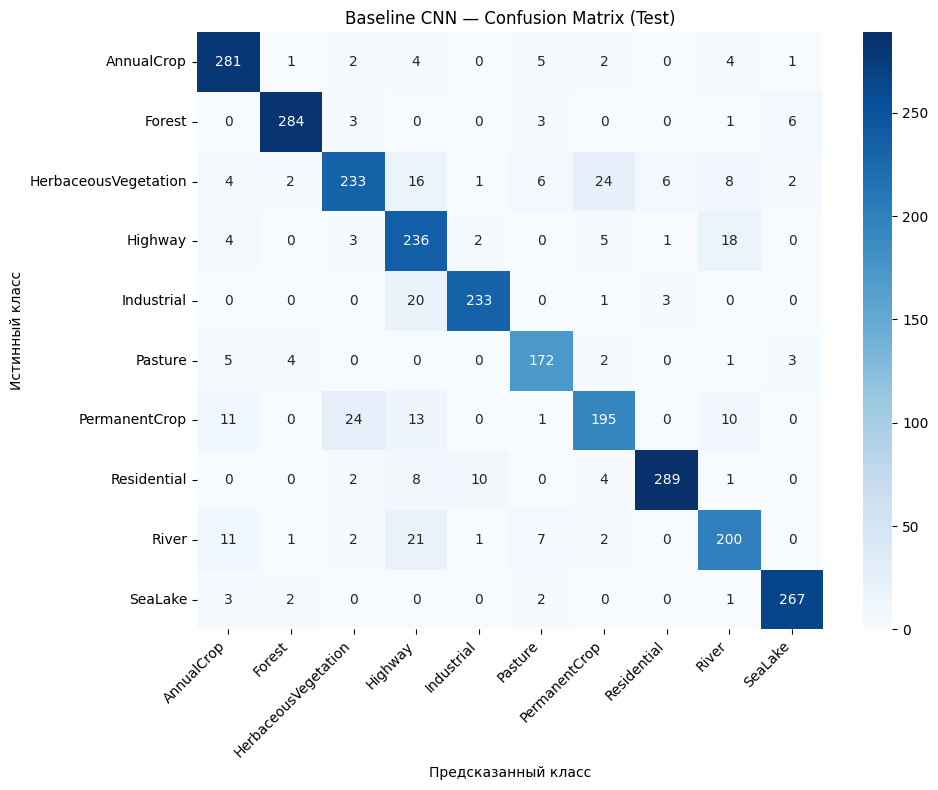

In [13]:
# Confusion Matrix для baseline
def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

fig = plot_confusion_matrix(baseline_labels, baseline_preds, CLASS_NAMES,
                            'Baseline CNN — Confusion Matrix (Test)')
fig.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Задание 2. Улучшение модели (максимальная оценка — 10)

### Аугментация данных

Обоснование выбора аугментаций для спутниковых снимков:
- **RandomHorizontalFlip** — снимки со спутника инвариантны к горизонтальному отражению (вид сверху)
- **RandomVerticalFlip** — аналогично, вертикальное отражение не меняет семантику
- **RandomRotation(15)** — небольшие повороты моделируют разные углы съёмки спутника
- **ColorJitter(brightness=0.2, contrast=0.2)** — вариации освещения в разное время суток/сезона

Для val/test аугментация **не** применяется — только `ToTensor()` + `Normalize()`.

In [14]:
# Аугментация для train
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

train_aug_ds = EuroSATSubset(full_dataset, train_indices, aug_transform)
train_aug_loader = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

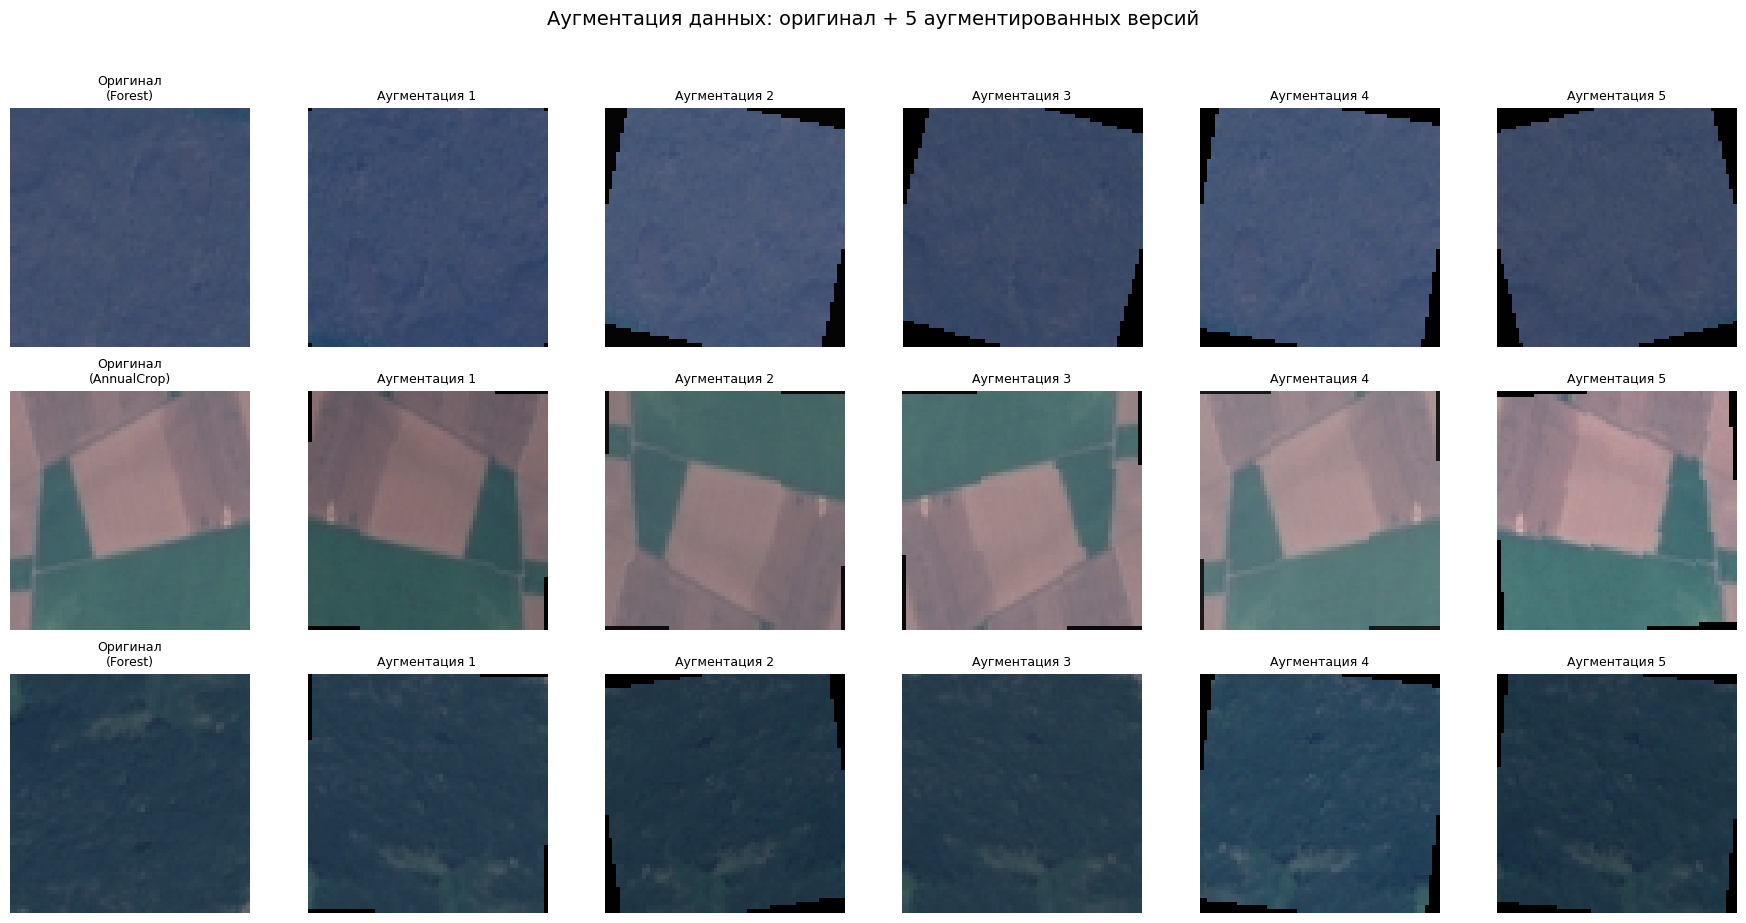

In [15]:
# Визуализация аугментированных изображений
# Показываем оригинал и 5 аугментированных версий для 3 случайных изображений
aug_vis_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Аугментация данных: оригинал + 5 аугментированных версий', fontsize=14, y=1.02)

sample_indices = [0, 1000, 5000]
for row, idx in enumerate(sample_indices):
    img_path, label = full_dataset.samples[train_indices[idx]]
    orig_img = Image.open(img_path).convert('RGB')

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f'Оригинал\n({CLASS_NAMES[label]})', fontsize=9)
    axes[row, 0].axis('off')

    for col in range(1, 6):
        aug_img = aug_vis_transform(orig_img)
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Аугментация {col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

### Серия экспериментов

**Правило:** одно изменение за раз. Каждый эксперимент наследует лучшую конфигурацию предыдущего шага.

In [16]:
# Хранилище результатов всех экспериментов
experiments = []

def log_experiment(num, name, arch, optim_str, epochs, val_acc, test_acc, note, history):
    experiments.append({
        'No': num, 'Что изменено': name, 'Архитектура': arch,
        'Оптимизатор, lr': optim_str, 'Эпох': epochs,
        'Val acc': f'{val_acc:.4f}', 'Test acc': test_acc,
        'Вывод': note, 'history': history
    })

# Записываем baseline
best_baseline_val = max(baseline_history['val_acc'])
log_experiment(0, 'Baseline (Задание 1)', '2 conv + 1 fc', 'Adam, 0.001',
               len(baseline_history['val_acc']), best_baseline_val,
               f'{baseline_test_acc:.4f}', 'Стартовая точка', baseline_history)
print(f'Baseline: Val Acc = {best_baseline_val:.4f}, Test Acc = {baseline_test_acc:.4f}')

Baseline: Val Acc = 0.8763, Test Acc = 0.8852


#### Эксперимент 1: Baseline + аугментация данных

Изменение: добавляем аугментацию (RandomHorizontalFlip, RandomVerticalFlip, RandomRotation, ColorJitter) к тем же 2 conv блокам.

Ожидание: аугментация может не дать прироста на мелкой архитектуре, т.к. модель недостаточно ёмкая для использования дополнительного разнообразия данных.

In [17]:
# Эксперимент 1: Baseline + аугментация
torch.manual_seed(SEED)
model_exp1 = BaselineCNN(NUM_CLASSES).to(device)
criterion_exp1 = nn.CrossEntropyLoss()
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)

print('=== Эксперимент 1: Baseline + аугментация ===')
history_exp1 = train_model(
    model_exp1, train_aug_loader, val_loader, criterion_exp1, optimizer_exp1,
    device, num_epochs=20, patience=5
)

best_val_exp1 = max(history_exp1['val_acc'])
log_experiment(1, '+ Аугментация', '2 conv + 1 fc', 'Adam, 0.001',
               len(history_exp1['val_acc']), best_val_exp1, '—',
               'Влияние аугментации на baseline', history_exp1)

=== Эксперимент 1: Baseline + аугментация ===
Epoch   1/20 | Train Loss: 1.4122 | Val Acc: 0.7044 | LR: 0.001000
Epoch   2/20 | Train Loss: 1.0461 | Val Acc: 0.6944 | LR: 0.001000
Epoch   3/20 | Train Loss: 0.9327 | Val Acc: 0.6963 | LR: 0.001000
Epoch   4/20 | Train Loss: 0.8692 | Val Acc: 0.7615 | LR: 0.001000
Epoch   5/20 | Train Loss: 0.8289 | Val Acc: 0.7763 | LR: 0.001000
Epoch   6/20 | Train Loss: 0.7990 | Val Acc: 0.8007 | LR: 0.001000
Epoch   7/20 | Train Loss: 0.7829 | Val Acc: 0.7996 | LR: 0.001000
Epoch   8/20 | Train Loss: 0.7545 | Val Acc: 0.7489 | LR: 0.001000
Epoch   9/20 | Train Loss: 0.7111 | Val Acc: 0.7496 | LR: 0.001000
Epoch  10/20 | Train Loss: 0.7039 | Val Acc: 0.8067 | LR: 0.001000
Epoch  11/20 | Train Loss: 0.6760 | Val Acc: 0.8159 | LR: 0.001000
Epoch  12/20 | Train Loss: 0.6452 | Val Acc: 0.8378 | LR: 0.001000
Epoch  13/20 | Train Loss: 0.6307 | Val Acc: 0.8493 | LR: 0.001000
Epoch  14/20 | Train Loss: 0.6282 | Val Acc: 0.8352 | LR: 0.001000
Epoch  15/20 | T

#### Эксперимент 2: Углубление архитектуры (3 conv блока)

Изменение: добавляем третий свёрточный блок (128 фильтров). Аугментация сохраняется.

In [18]:
# Эксперимент 2: 3 conv блока + аугментация
class CNN_3Block(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 64x64 → 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 32x32 → 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 16x16 → 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch.manual_seed(SEED)
model_exp2 = CNN_3Block(NUM_CLASSES).to(device)
criterion_exp2 = nn.CrossEntropyLoss()
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)

print('=== Эксперимент 2: 3 conv блока + аугментация ===')
print(f'Параметров: {sum(p.numel() for p in model_exp2.parameters()):,}')
history_exp2 = train_model(
    model_exp2, train_aug_loader, val_loader, criterion_exp2, optimizer_exp2,
    device, num_epochs=25, patience=5
)

best_val_exp2 = max(history_exp2['val_acc'])
log_experiment(2, '3 conv блока', '3 conv + 1 fc', 'Adam, 0.001',
               len(history_exp2['val_acc']), best_val_exp2, '—',
               'Углубление архитектуры', history_exp2)

=== Эксперимент 2: 3 conv блока + аугментация ===
Параметров: 2,193,674
Epoch   1/25 | Train Loss: 1.2878 | Val Acc: 0.7174 | LR: 0.001000
Epoch   2/25 | Train Loss: 0.9494 | Val Acc: 0.7770 | LR: 0.001000
Epoch   3/25 | Train Loss: 0.8458 | Val Acc: 0.7804 | LR: 0.001000
Epoch   4/25 | Train Loss: 0.7697 | Val Acc: 0.7837 | LR: 0.001000
Epoch   5/25 | Train Loss: 0.7344 | Val Acc: 0.8078 | LR: 0.001000
Epoch   6/25 | Train Loss: 0.6946 | Val Acc: 0.8507 | LR: 0.001000
Epoch   7/25 | Train Loss: 0.6479 | Val Acc: 0.8567 | LR: 0.001000
Epoch   8/25 | Train Loss: 0.6285 | Val Acc: 0.8526 | LR: 0.001000
Epoch   9/25 | Train Loss: 0.5915 | Val Acc: 0.8463 | LR: 0.001000
Epoch  10/25 | Train Loss: 0.5284 | Val Acc: 0.8437 | LR: 0.001000
Epoch  11/25 | Train Loss: 0.5221 | Val Acc: 0.8641 | LR: 0.001000
Epoch  12/25 | Train Loss: 0.4897 | Val Acc: 0.8959 | LR: 0.001000
Epoch  13/25 | Train Loss: 0.4737 | Val Acc: 0.9004 | LR: 0.001000
Epoch  14/25 | Train Loss: 0.4524 | Val Acc: 0.9037 | LR:

#### Эксперимент 3: AdamW + weight_decay

Изменение: замена Adam на AdamW с L2-регуляризацией (weight_decay=1e-4). Архитектура 3 conv блока.

In [19]:
# Эксперимент 3: AdamW + weight_decay
torch.manual_seed(SEED)
model_exp3 = CNN_3Block(NUM_CLASSES).to(device)
criterion_exp3 = nn.CrossEntropyLoss()
optimizer_exp3 = optim.AdamW(model_exp3.parameters(), lr=0.001, weight_decay=1e-4)

print('=== Эксперимент 3: AdamW + weight_decay ===')
history_exp3 = train_model(
    model_exp3, train_aug_loader, val_loader, criterion_exp3, optimizer_exp3,
    device, num_epochs=25, patience=5
)

best_val_exp3 = max(history_exp3['val_acc'])
log_experiment(3, 'AdamW + weight_decay', '3 conv + 1 fc', 'AdamW, 0.001, wd=1e-4',
               len(history_exp3['val_acc']), best_val_exp3, '—',
               'L2-регуляризация через AdamW', history_exp3)

=== Эксперимент 3: AdamW + weight_decay ===
Epoch   1/25 | Train Loss: 1.2902 | Val Acc: 0.7137 | LR: 0.001000
Epoch   2/25 | Train Loss: 0.9478 | Val Acc: 0.7644 | LR: 0.001000
Epoch   3/25 | Train Loss: 0.8483 | Val Acc: 0.7648 | LR: 0.001000
Epoch   4/25 | Train Loss: 0.7688 | Val Acc: 0.8119 | LR: 0.001000
Epoch   5/25 | Train Loss: 0.7221 | Val Acc: 0.8348 | LR: 0.001000
Epoch   6/25 | Train Loss: 0.6997 | Val Acc: 0.8385 | LR: 0.001000
Epoch   7/25 | Train Loss: 0.6475 | Val Acc: 0.8515 | LR: 0.001000
Epoch   8/25 | Train Loss: 0.6192 | Val Acc: 0.8352 | LR: 0.001000
Epoch   9/25 | Train Loss: 0.5973 | Val Acc: 0.8493 | LR: 0.001000
Epoch  10/25 | Train Loss: 0.5379 | Val Acc: 0.8215 | LR: 0.001000
Epoch  11/25 | Train Loss: 0.5273 | Val Acc: 0.8804 | LR: 0.001000
Epoch  12/25 | Train Loss: 0.4939 | Val Acc: 0.9044 | LR: 0.001000
Epoch  13/25 | Train Loss: 0.4720 | Val Acc: 0.9052 | LR: 0.001000
Epoch  14/25 | Train Loss: 0.4414 | Val Acc: 0.9059 | LR: 0.001000
Epoch  15/25 | Tra

#### Эксперимент 4: + Learning Rate Scheduler (ReduceLROnPlateau)

Изменение: добавляем ReduceLROnPlateau (patience=3, factor=0.5) — автоматическое снижение lr при стагнации.

In [22]:
# Эксперимент 4: + LR Scheduler
torch.manual_seed(SEED)
model_exp4 = CNN_3Block(NUM_CLASSES).to(device)
criterion_exp4 = nn.CrossEntropyLoss()
optimizer_exp4 = optim.AdamW(model_exp4.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_exp4 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp4, mode='max', patience=3, factor=0.5
)

print('=== Эксперимент 4: + LR Scheduler ===')
history_exp4 = train_model(
    model_exp4, train_aug_loader, val_loader, criterion_exp4, optimizer_exp4,
    device, num_epochs=30, patience=7, scheduler=scheduler_exp4
)

best_val_exp4 = max(history_exp4['val_acc'])
log_experiment(4, '+ LR Scheduler', '3 conv + 1 fc', 'AdamW + RLROP',
               len(history_exp4['val_acc']), best_val_exp4, '—',
               'Адаптивный learning rate', history_exp4)

=== Эксперимент 4: + LR Scheduler ===
Epoch   1/30 | Train Loss: 1.2943 | Val Acc: 0.7070 | LR: 0.001000
Epoch   2/30 | Train Loss: 0.9667 | Val Acc: 0.7719 | LR: 0.001000
Epoch   3/30 | Train Loss: 0.8568 | Val Acc: 0.7704 | LR: 0.001000
Epoch   4/30 | Train Loss: 0.7728 | Val Acc: 0.7767 | LR: 0.001000
Epoch   5/30 | Train Loss: 0.7358 | Val Acc: 0.8289 | LR: 0.001000
Epoch   6/30 | Train Loss: 0.7048 | Val Acc: 0.8533 | LR: 0.001000
Epoch   7/30 | Train Loss: 0.6511 | Val Acc: 0.8341 | LR: 0.001000
Epoch   8/30 | Train Loss: 0.6281 | Val Acc: 0.8459 | LR: 0.001000
Epoch   9/30 | Train Loss: 0.5975 | Val Acc: 0.8019 | LR: 0.001000
Epoch  10/30 | Train Loss: 0.5493 | Val Acc: 0.8144 | LR: 0.000500
Epoch  11/30 | Train Loss: 0.4691 | Val Acc: 0.8970 | LR: 0.000500
Epoch  12/30 | Train Loss: 0.4309 | Val Acc: 0.9000 | LR: 0.000500
Epoch  13/30 | Train Loss: 0.4147 | Val Acc: 0.9048 | LR: 0.000500
Epoch  14/30 | Train Loss: 0.4039 | Val Acc: 0.8978 | LR: 0.000500
Epoch  15/30 | Train Los

#### Эксперимент 5: 4 conv блока + LeakyReLU + AdaptiveAvgPool

Изменение: более глубокая архитектура (4 conv блока, 32→64→128→256 фильтров), LeakyReLU вместо ReLU, AdaptiveAvgPool2d(1) вместо фиксированного flatten.

In [24]:
# Эксперимент 5: 4 conv блока + LeakyReLU
class CNN_4Block(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 64x64 → 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            # Block 2: 32x32 → 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            # Block 3: 16x16 → 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            # Block 4: 8x8 → 1x1 (AdaptiveAvgPool)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch.manual_seed(SEED)
model_exp5 = CNN_4Block(NUM_CLASSES).to(device)
criterion_exp5 = nn.CrossEntropyLoss()
optimizer_exp5 = optim.AdamW(model_exp5.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_exp5 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp5, mode='max', patience=3, factor=0.5
)

print('=== Эксперимент 5: 4 conv блока + LeakyReLU ===')
print(f'Параметров: {sum(p.numel() for p in model_exp5.parameters()):,}')
history_exp5 = train_model(
    model_exp5, train_aug_loader, val_loader, criterion_exp5, optimizer_exp5,
    device, num_epochs=30, patience=7, scheduler=scheduler_exp5
)

best_val_exp5 = max(history_exp5['val_acc'])
log_experiment(5, '4 conv + LeakyReLU + AdaptivePool', '4 conv + 1 fc', 'AdamW + RLROP',
               len(history_exp5['val_acc']), best_val_exp5, '—',
               'Глубокая архитектура с LeakyReLU', history_exp5)

=== Эксперимент 5: 4 conv блока + LeakyReLU ===
Параметров: 423,562
Epoch   1/30 | Train Loss: 1.0662 | Val Acc: 0.7163 | LR: 0.001000
Epoch   2/30 | Train Loss: 0.7559 | Val Acc: 0.7426 | LR: 0.001000
Epoch   3/30 | Train Loss: 0.6659 | Val Acc: 0.7459 | LR: 0.001000
Epoch   4/30 | Train Loss: 0.5956 | Val Acc: 0.7756 | LR: 0.001000
Epoch   5/30 | Train Loss: 0.5484 | Val Acc: 0.7807 | LR: 0.001000
Epoch   6/30 | Train Loss: 0.5089 | Val Acc: 0.8730 | LR: 0.001000
Epoch   7/30 | Train Loss: 0.4641 | Val Acc: 0.8215 | LR: 0.001000
Epoch   8/30 | Train Loss: 0.4233 | Val Acc: 0.9070 | LR: 0.001000
Epoch   9/30 | Train Loss: 0.3926 | Val Acc: 0.9030 | LR: 0.001000
Epoch  10/30 | Train Loss: 0.3928 | Val Acc: 0.8656 | LR: 0.001000
Epoch  11/30 | Train Loss: 0.3680 | Val Acc: 0.8648 | LR: 0.001000
Epoch  12/30 | Train Loss: 0.3463 | Val Acc: 0.8244 | LR: 0.000500
Epoch  13/30 | Train Loss: 0.2914 | Val Acc: 0.9156 | LR: 0.000500
Epoch  14/30 | Train Loss: 0.2706 | Val Acc: 0.9285 | LR: 0.0

#### Эксперимент 6: Уменьшение learning rate до 0.0001

Изменение: снижаем начальный lr с 0.001 до 0.0001 на лучшей архитектуре (4 conv блока).

In [25]:
# Эксперимент 6: lr=0.0001
torch.manual_seed(SEED)
model_exp6 = CNN_4Block(NUM_CLASSES).to(device)
criterion_exp6 = nn.CrossEntropyLoss()
optimizer_exp6 = optim.AdamW(model_exp6.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler_exp6 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp6, mode='max', patience=3, factor=0.5
)

print('=== Эксперимент 6: lr=0.0001 ===')
history_exp6 = train_model(
    model_exp6, train_aug_loader, val_loader, criterion_exp6, optimizer_exp6,
    device, num_epochs=30, patience=7, scheduler=scheduler_exp6
)

best_val_exp6 = max(history_exp6['val_acc'])
log_experiment(6, 'lr=0.0001', '4 conv + 1 fc', 'AdamW, 0.0001 + RLROP',
               len(history_exp6['val_acc']), best_val_exp6, '—',
               'Меньший начальный lr', history_exp6)

=== Эксперимент 6: lr=0.0001 ===
Epoch   1/30 | Train Loss: 1.4050 | Val Acc: 0.7322 | LR: 0.000100
Epoch   2/30 | Train Loss: 0.9065 | Val Acc: 0.7852 | LR: 0.000100
Epoch   3/30 | Train Loss: 0.7736 | Val Acc: 0.8007 | LR: 0.000100
Epoch   4/30 | Train Loss: 0.7035 | Val Acc: 0.8144 | LR: 0.000100
Epoch   5/30 | Train Loss: 0.6607 | Val Acc: 0.8281 | LR: 0.000100
Epoch   6/30 | Train Loss: 0.6097 | Val Acc: 0.8341 | LR: 0.000100
Epoch   7/30 | Train Loss: 0.5843 | Val Acc: 0.8515 | LR: 0.000100
Epoch   8/30 | Train Loss: 0.5548 | Val Acc: 0.8626 | LR: 0.000100
Epoch   9/30 | Train Loss: 0.5229 | Val Acc: 0.8667 | LR: 0.000100
Epoch  10/30 | Train Loss: 0.5119 | Val Acc: 0.8696 | LR: 0.000100
Epoch  11/30 | Train Loss: 0.4884 | Val Acc: 0.8885 | LR: 0.000100
Epoch  12/30 | Train Loss: 0.4677 | Val Acc: 0.8756 | LR: 0.000100
Epoch  13/30 | Train Loss: 0.4519 | Val Acc: 0.8763 | LR: 0.000100
Epoch  14/30 | Train Loss: 0.4326 | Val Acc: 0.8933 | LR: 0.000100
Epoch  15/30 | Train Loss: 0.

---

### Таблица экспериментов и финальная оценка

In [26]:
# Таблица экспериментов
import pandas as pd

df_experiments = pd.DataFrame([
    {k: v for k, v in exp.items() if k != 'history'}
    for exp in experiments
])
print('=== Таблица экспериментов ===')
print(df_experiments.to_string(index=False))
print()

# Определяем лучший эксперимент по val acc
best_exp_idx = max(range(len(experiments)), key=lambda i: float(experiments[i]['Val acc']))
best_exp = experiments[best_exp_idx]
print(f'Лучший эксперимент: No.{best_exp["No"]} — {best_exp["Что изменено"]} (Val Acc: {best_exp["Val acc"]})')

=== Таблица экспериментов ===
 No                      Что изменено   Архитектура       Оптимизатор, lr  Эпох Val acc Test acc                            Вывод
  0              Baseline (Задание 1) 2 conv + 1 fc           Adam, 0.001    20  0.8763   0.8852                  Стартовая точка
  1                     + Аугментация 2 conv + 1 fc           Adam, 0.001    20  0.8696        —  Влияние аугментации на baseline
  2                      3 conv блока 3 conv + 1 fc           Adam, 0.001    25  0.9281        —           Углубление архитектуры
  3              AdamW + weight_decay 3 conv + 1 fc AdamW, 0.001, wd=1e-4    25  0.9237        —     L2-регуляризация через AdamW
  4                    + LR Scheduler 3 conv + 1 fc         AdamW + RLROP    30  0.9493        —         Адаптивный learning rate
  5 4 conv + LeakyReLU + AdaptivePool 4 conv + 1 fc         AdamW + RLROP    30  0.9507        — Глубокая архитектура с LeakyReLU
  6                         lr=0.0001 4 conv + 1 fc AdamW, 0

In [31]:
# Финальная оценка ВСЕХ моделей на тесте
all_models = {
    0: (model, 'Baseline'),
    1: (model_exp1, '+ Аугментация'),
    2: (model_exp2, '3 conv блока'),
    3: (model_exp3, 'AdamW + weight_decay'),
    4: (model_exp4, '+ LR Scheduler'),
    5: (model_exp5, '4 conv + LeakyReLU'),
    6: (model_exp6, 'lr=0.0001'),
}

print('=== Test Accuracy всех моделей ===')
for exp_no, (exp_model, exp_name) in all_models.items():
    preds, labels = get_predictions(exp_model, test_loader, device)
    acc = (preds == labels).mean()
    experiments[exp_no]['Test acc'] = f'{acc:.4f}'
    print(f'Эксп. {exp_no}: {exp_name:25s} — Test Acc: {acc:.4f}')

# Classification Report только для лучшей модели
best_exp_idx = max(range(len(experiments)), key=lambda i: float(experiments[i]['Test acc']))
best_exp = experiments[best_exp_idx]
best_model_final = all_models[best_exp['No']][0]
final_preds, final_labels = get_predictions(best_model_final, test_loader, device)
final_test_acc = (final_preds == final_labels).mean()

print(f'\n=== Classification Report лучшей модели (Эксп. {best_exp["No"]}) ===')
print(classification_report(final_labels, final_preds, target_names=CLASS_NAMES))

=== Test Accuracy всех моделей ===
Эксп. 0: Baseline                  — Test Acc: 0.8852
Эксп. 1: + Аугментация             — Test Acc: 0.8744
Эксп. 2: 3 conv блока              — Test Acc: 0.9315
Эксп. 3: AdamW + weight_decay      — Test Acc: 0.9293
Эксп. 4: + LR Scheduler            — Test Acc: 0.9426
Эксп. 5: 4 conv + LeakyReLU        — Test Acc: 0.9519
Эксп. 6: lr=0.0001                 — Test Acc: 0.9363

=== Classification Report лучшей модели (Эксп. 5) ===
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.96      0.95       300
              Forest       0.97      0.98      0.97       297
HerbaceousVegetation       0.97      0.88      0.92       302
             Highway       0.95      0.96      0.95       269
          Industrial       0.96      0.96      0.96       257
             Pasture       0.94      0.92      0.93       187
       PermanentCrop       0.89      0.94      0.91       254
         Residential       0.98    

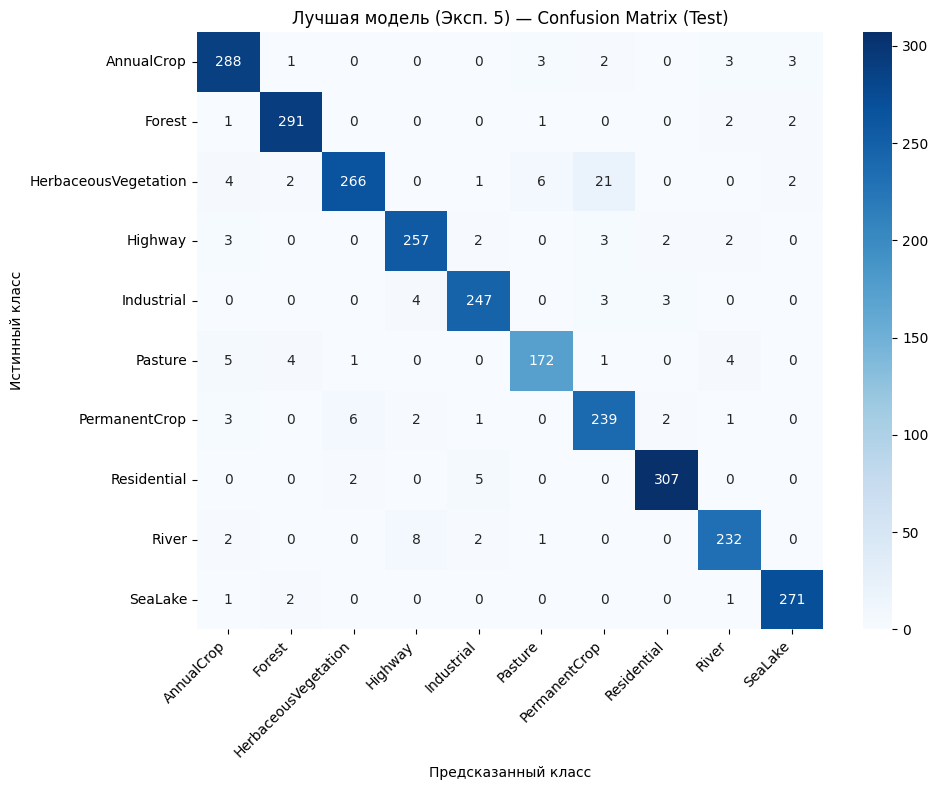

In [28]:
# Confusion Matrix для лучшей модели
fig = plot_confusion_matrix(final_labels, final_preds, CLASS_NAMES,
                            f'Лучшая модель (Эксп. {best_exp["No"]}) — Confusion Matrix (Test)')
fig.savefig('final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

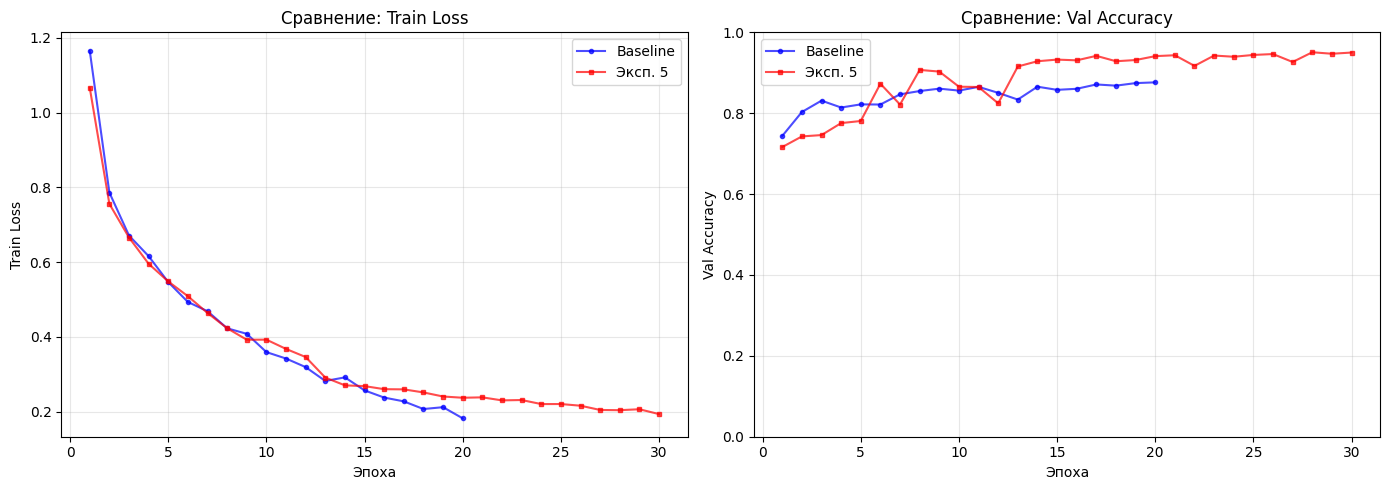

In [29]:
# Сравнительные графики: Baseline vs Лучшая модель
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

baseline_hist = experiments[0]['history']
best_hist = experiments[best_exp_idx]['history']

# Train Loss
epochs_b = range(1, len(baseline_hist['train_loss']) + 1)
epochs_f = range(1, len(best_hist['train_loss']) + 1)

ax1.plot(epochs_b, baseline_hist['train_loss'], 'b-o', markersize=3, label='Baseline', alpha=0.7)
ax1.plot(epochs_f, best_hist['train_loss'], 'r-s', markersize=3,
         label=f'Эксп. {best_exp["No"]}', alpha=0.7)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Train Loss')
ax1.set_title('Сравнение: Train Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Val Accuracy
ax2.plot(epochs_b, baseline_hist['val_acc'], 'b-o', markersize=3, label='Baseline', alpha=0.7)
ax2.plot(epochs_f, best_hist['val_acc'], 'r-s', markersize=3,
         label=f'Эксп. {best_exp["No"]}', alpha=0.7)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Val Accuracy')
ax2.set_title('Сравнение: Val Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('comparison_baseline_vs_best.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Итоговая таблица (test acc для всех моделей)
df_final = pd.DataFrame([
    {k: v for k, v in exp.items() if k != 'history'}
    for exp in experiments
])
print('=== Итоговая таблица экспериментов ===')
print(df_final.to_string(index=False))

baseline_test = float(experiments[0]['Test acc'])
print(f'\n=== Итоги ===')
print(f'Baseline Test Accuracy: {baseline_test:.4f}')
print(f'Лучшая модель Test Accuracy: {final_test_acc:.4f}')
print(f'Улучшение: +{(final_test_acc - baseline_test)*100:.2f}%')
print(f'Случайное угадывание: {1/NUM_CLASSES:.4f} ({100/NUM_CLASSES:.1f}%)')

=== Итоговая таблица экспериментов ===
 No                      Что изменено   Архитектура       Оптимизатор, lr  Эпох Val acc Test acc                            Вывод
  0              Baseline (Задание 1) 2 conv + 1 fc           Adam, 0.001    20  0.8763   0.8852                  Стартовая точка
  1                     + Аугментация 2 conv + 1 fc           Adam, 0.001    20  0.8696   0.8744  Влияние аугментации на baseline
  2                      3 conv блока 3 conv + 1 fc           Adam, 0.001    25  0.9281   0.9315           Углубление архитектуры
  3              AdamW + weight_decay 3 conv + 1 fc AdamW, 0.001, wd=1e-4    25  0.9237   0.9293     L2-регуляризация через AdamW
  4                    + LR Scheduler 3 conv + 1 fc         AdamW + RLROP    30  0.9493   0.9426         Адаптивный learning rate
  5 4 conv + LeakyReLU + AdaptivePool 4 conv + 1 fc         AdamW + RLROP    30  0.9507   0.9519 Глубокая архитектура с LeakyReLU
  6                         lr=0.0001 4 conv + 1 fc

---

## Выводы

**Baseline CNN** (2 conv блока, Adam lr=0.001) достиг 87.63% на валидации и 88.52% на тесте — значительно выше случайного угадывания (10%).

Результаты серии экспериментов:

| No | Изменение | Val Acc | Test Acc |
|---|---|---|---|
| 0 | Baseline | 87.63% | 88.52% |
| 1 | + Аугментация | 86.96% | 87.44% |
| 2 | 3 conv блока | 92.81% | 93.15% |
| 3 | AdamW + weight_decay | 92.37% | 92.93% |
| 4 | + LR Scheduler | 94.93% | 94.26% |
| 5 | **4 conv + LeakyReLU** | **95.07%** | **95.19%** |
| 6 | lr=0.0001 | 93.48% | 93.63% |

Ключевые наблюдения:

1. **Аугментация на мелкой архитектуре (Эксп. 1)** незначительно ухудшила результат (-0.67% val). Модель с 2 conv блоками недостаточно ёмкая, чтобы извлечь пользу из расширенных данных.
2. **Углубление до 3 conv блоков (Эксп. 2)** дало самый большой прирост: +5.18% val acc. Дополнительный слой позволяет модели извлекать более сложные иерархические признаки.
3. **AdamW (Эксп. 3)** — L2-регуляризация через weight_decay не дала заметного прироста при достаточном Dropout.
4. **LR Scheduler (Эксп. 4)** — ReduceLROnPlateau дал +2.12% val acc, позволяя модели точнее сходиться на поздних эпохах.
5. **4 conv блока + LeakyReLU + AdaptiveAvgPool (Эксп. 5)** — лучший результат: **95.19% test acc**. AdaptiveAvgPool резко уменьшил количество параметров (423K vs 2.2M у 3-block), а LeakyReLU предотвратил «мёртвые нейроны».
6. **Уменьшение lr (Эксп. 6)** — lr=0.0001 замедлил сходимость без улучшения итогового качества.

**Итог:** лучшая модель (Эксп. 5) улучшила baseline на **+6.67%** test accuracy (88.52% → 95.19%). Наибольший вклад внесли углубление архитектуры и LR Scheduler.